In [2]:
import os

ims_dir = "../data/raw/ims"
print("Top-level contents:", os.listdir(ims_dir))

Top-level contents: ['.gitkeep', '4. Bearings']


In [3]:
inner_dir = os.path.join(ims_dir, "4. Bearings")
print("Inside '4. Bearings':", os.listdir(inner_dir))

Inside '4. Bearings': ['IMS', 'IMS.7z']


In [4]:
inner_ims = os.path.join(inner_dir, "IMS")
print("Inside 'IMS':", os.listdir(inner_ims))

Inside 'IMS': ['1st_test.rar', '2nd_test.rar', '3rd_test.rar', 'Readme Document for IMS Bearing Data.pdf']


In [5]:
print("1st_test contents (first 5):", sorted(os.listdir("../data/raw/ims/4. Bearings/IMS/1st_test"))[:5])
print("2nd_test contents (first 5):", sorted(os.listdir("../data/raw/ims/4. Bearings/IMS/2nd_test"))[:5])
print("3rd_test contents:", os.listdir("../data/raw/ims/4. Bearings/IMS/3rd_test"))

1st_test contents (first 5): ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13']
2nd_test contents (first 5): ['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39', '2004.02.12.11.02.39', '2004.02.12.11.12.39']


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw/ims/4. Bearings/IMS/3rd_test'

In [6]:
parent = "../data/raw/ims/4. Bearings/IMS"
print(os.listdir(parent))

['1st_test', '1st_test.rar', '2nd_test', '2nd_test.rar', '3rd_test.rar', '4th_test', 'Readme Document for IMS Bearing Data.pdf']


In [7]:
test3_path = "../data/raw/ims/4. Bearings/IMS/4th_test"
test3_files = os.listdir(test3_path)
print(f"Number of files in 4th_test (= Set 3): {len(test3_files)}")
print("First 5 filenames:", sorted(test3_files)[:5])

Number of files in 4th_test (= Set 3): 1
First 5 filenames: ['txt']


In [8]:
txt_path = os.path.join(test3_path, "txt")
print("Is 'txt' a directory?", os.path.isdir(txt_path))

if os.path.isdir(txt_path):
    inner_files = os.listdir(txt_path)
    print(f"Number of files inside: {len(inner_files)}")
    print("First 5 filenames:", sorted(inner_files)[:5])

Is 'txt' a directory? True
Number of files inside: 6324
First 5 filenames: ['2004.03.04.09.27.46', '2004.03.04.09.32.46', '2004.03.04.09.42.46', '2004.03.04.09.52.46', '2004.03.04.10.02.46']


In [9]:
sample_file = os.path.join(txt_path, "2004.03.04.09.27.46")
sample_data = pd.read_csv(sample_file, sep="\t", header=None)
print("Shape:", sample_data.shape)
print(sample_data.head())

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

sample_file = os.path.join(txt_path, "2004.03.04.09.27.46")
sample_data = pd.read_csv(sample_file, sep="\t", header=None)
print("Shape:", sample_data.shape)
print(sample_data.head())

Shape: (20480, 4)
       0      1      2      3
0  0.034  0.264  0.039 -0.046
1  0.103  0.083 -0.061 -0.012
2  0.095 -0.039 -0.007  0.039
3  0.000  0.110  0.022 -0.002
4  0.005  0.154 -0.127 -0.020


In [11]:
from datetime import datetime

def parse_ims_timestamp(filename):
    # Format: "2003.10.22.12.06.24" -> datetime object
    return datetime.strptime(filename, "%Y.%m.%d.%H.%M.%S")

test1_path = "../data/raw/ims/4. Bearings/IMS/1st_test"
test1_files = sorted(os.listdir(test1_path))  # sort alphabetically = sort chronologically, since timestamps are zero-padded

timestamps = [parse_ims_timestamp(f) for f in test1_files]
print(f"Total files: {len(test1_files)}")
print(f"First timestamp: {timestamps[0]}")
print(f"Last timestamp: {timestamps[-1]}")
print(f"Total duration: {timestamps[-1] - timestamps[0]}")

Total files: 2156
First timestamp: 2003-10-22 12:06:24
Last timestamp: 2003-11-25 23:39:56
Total duration: 34 days, 11:33:32


              filename           timestamp   rul_hours
0  2003.10.22.12.06.24 2003-10-22 12:06:24  827.558889
1  2003.10.22.12.09.13 2003-10-22 12:09:13  827.511944
2  2003.10.22.12.14.13 2003-10-22 12:14:13  827.428611
3  2003.10.22.12.19.13 2003-10-22 12:19:13  827.345278
4  2003.10.22.12.24.13 2003-10-22 12:24:13  827.261944
                 filename           timestamp  rul_hours
2151  2003.11.25.16.07.32 2003-11-25 16:07:32   7.540000
2152  2003.11.25.23.13.21 2003-11-25 23:13:21   0.443056
2153  2003.11.25.23.19.56 2003-11-25 23:19:56   0.333333
2154  2003.11.25.23.29.56 2003-11-25 23:29:56   0.166667
2155  2003.11.25.23.39.56 2003-11-25 23:39:56   0.000000


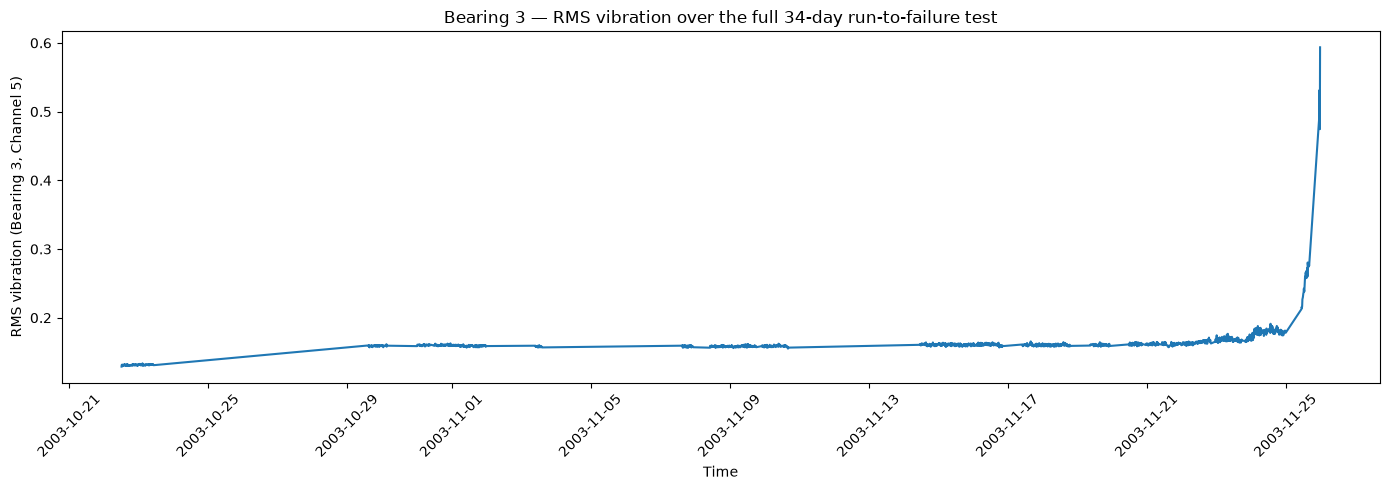

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build a table: one row per file, with its timestamp and RUL (time until the LAST file)
final_time = timestamps[-1]
rul_hours = [(final_time - t).total_seconds() / 3600 for t in timestamps]

file_table = pd.DataFrame({
    "filename": test1_files,
    "timestamp": timestamps,
    "rul_hours": rul_hours
})

print(file_table.head())
print(file_table.tail())

# Load Bearing 3's two channels (readme: Bearing 3 = Ch 5 & 6, so columns 4 & 5, zero-indexed) 
# for EVERY file, and compute one simple summary (RMS) per file first - same "look before touching" 
# instinct as every dataset before this one
bearing3_rms = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    data = pd.read_csv(filepath, sep="\t", header=None)
    ch5 = data[4].values  # Bearing 3, channel 5 (x-axis)
    rms = np.sqrt(np.mean(ch5**2))
    bearing3_rms.append(rms)

file_table["bearing3_ch5_rms"] = bearing3_rms

plt.figure(figsize=(14, 5))
plt.plot(file_table["timestamp"], file_table["bearing3_ch5_rms"])
plt.xlabel("Time")
plt.ylabel("RMS vibration (Bearing 3, Channel 5)")
plt.title("Bearing 3 — RMS vibration over the full 34-day run-to-failure test")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Use a simple statistical threshold: define "degradation onset" as the point where 
# RMS first exceeds some number of standard deviations above the healthy baseline

healthy_period = file_table[file_table["timestamp"] < "2003-11-15"]  # clearly flat region, conservative cutoff
baseline_mean = healthy_period["bearing3_ch5_rms"].mean()
baseline_std = healthy_period["bearing3_ch5_rms"].std()

threshold = baseline_mean + 3 * baseline_std  # 3-sigma, a standard "this is genuinely unusual" cutoff

print(f"Healthy baseline mean: {baseline_mean:.4f}, std: {baseline_std:.4f}")
print(f"Degradation threshold (3-sigma): {threshold:.4f}")

# Find the first file that crosses this threshold and STAYS above it (not just a one-off noise spike)
above_threshold = file_table["bearing3_ch5_rms"] > threshold
file_table["above_threshold"] = above_threshold

onset_candidates = file_table[above_threshold]
print(f"\nFirst file crossing threshold: {onset_candidates.iloc[0]['timestamp']}")
print(f"RUL at that point: {onset_candidates.iloc[0]['rul_hours']:.1f} hours")

Healthy baseline mean: 0.1546, std: 0.0103
Degradation threshold (3-sigma): 0.1855

First file crossing threshold: 2003-11-24 04:41:24
RUL at that point: 43.0 hours


In [14]:
# Check: of all files AFTER the detected onset, what fraction stay above threshold?
after_onset = file_table[file_table["timestamp"] >= "2003-11-24 04:41:24"]
pct_above = after_onset["above_threshold"].mean()
print(f"Files after onset: {len(after_onset)}")
print(f"Percentage staying above threshold: {pct_above*100:.1f}%")

# Also look at the few files immediately before onset, to see if it's a clean before/after split
around_onset = file_table[(file_table["timestamp"] >= "2003-11-23 12:00:00") & 
                            (file_table["timestamp"] <= "2003-11-24 12:00:00")]
print(around_onset[["timestamp", "bearing3_ch5_rms", "above_threshold"]])

Files after onset: 135
Percentage staying above threshold: 32.6%
               timestamp  bearing3_ch5_rms  above_threshold
1934 2003-11-23 12:06:56          0.167088            False
1935 2003-11-23 12:16:56          0.167968            False
1936 2003-11-23 12:26:56          0.168703            False
1937 2003-11-23 12:36:56          0.166939            False
1938 2003-11-23 12:46:56          0.166398            False
...                  ...               ...              ...
2046 2003-11-24 10:11:24          0.177364            False
2047 2003-11-24 10:21:24          0.175940            False
2048 2003-11-24 10:31:24          0.175149            False
2049 2003-11-24 10:41:24          0.184315            False
2050 2003-11-24 10:51:24          0.177581            False

[117 rows x 3 columns]


In [15]:
def find_robust_onset(df, threshold, min_consecutive=5):
    above = df["bearing3_ch5_rms"] > threshold
    # Find the first index where 'min_consecutive' consecutive True values start
    for i in range(len(above) - min_consecutive):
        if above.iloc[i:i+min_consecutive].all():
            return df.iloc[i]
    return None

robust_onset = find_robust_onset(file_table, threshold, min_consecutive=5)
print("Robust onset point:")
print(robust_onset[["timestamp", "bearing3_ch5_rms", "rul_hours"]])

# Re-check: does the signal stay above threshold consistently from THIS point onward?
after_robust_onset = file_table[file_table["timestamp"] >= robust_onset["timestamp"]]
pct_above_robust = after_robust_onset["above_threshold"].mean()
print(f"\nFiles after robust onset: {len(after_robust_onset)}")
print(f"Percentage staying above threshold: {pct_above_robust*100:.1f}%")

Robust onset point:
timestamp           2003-11-25 10:47:32
bearing3_ch5_rms               0.212515
rul_hours                     12.873333
Name: 2119, dtype: object

Files after robust onset: 37
Percentage staying above threshold: 100.0%


In [16]:
# Build a richer feature set for Bearing 3 across ALL 2156 files, not just RMS
def extract_ims_features(filepath, column_idx):
    data = pd.read_csv(filepath, sep="\t", header=None)
    signal = data[column_idx].values
    return {
        "rms": np.sqrt(np.mean(signal**2)),
        "kurtosis": pd.Series(signal).kurtosis(),
        "peak_to_peak": signal.max() - signal.min(),
        "std": signal.std(),
        "mean_abs": np.mean(np.abs(signal)),
    }

bearing3_features = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    feats = extract_ims_features(filepath, column_idx=4)  # Bearing 3, Ch5
    bearing3_features.append(feats)

bearing3_df = pd.DataFrame(bearing3_features)
bearing3_df["timestamp"] = timestamps
bearing3_df["rul_hours"] = rul_hours

# Label: degrading = 1 if at or after the validated robust onset point, else 0
onset_time = robust_onset["timestamp"]
bearing3_df["label"] = (bearing3_df["timestamp"] >= onset_time).astype(int)

print(bearing3_df["label"].value_counts())
print(bearing3_df.head())

label
0    2119
1      37
Name: count, dtype: int64
        rms  kurtosis  peak_to_peak       std  mean_abs           timestamp  \
0  0.128887  0.405831         0.896  0.091461  0.106148 2003-10-22 12:06:24   
1  0.129562  0.446120         1.059  0.091732  0.106660 2003-10-22 12:09:13   
2  0.131339  0.390100         0.987  0.091813  0.108741 2003-10-22 12:14:13   
3  0.131083  0.262319         0.874  0.092385  0.108073 2003-10-22 12:19:13   
4  0.131307  0.326564         0.998  0.091932  0.108453 2003-10-22 12:24:13   

    rul_hours  label  
0  827.558889      0  
1  827.511944      0  
2  827.428611      0  
3  827.345278      0  
4  827.261944      0  


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

feature_cols_ims = ["rms", "kurtosis", "peak_to_peak", "std", "mean_abs"]
X = bearing3_df[feature_cols_ims]
y = bearing3_df["label"]

# Stratified split - ensures both train and test get a proportional share of the rare "degrading" class
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} ({y_train.sum()} degrading)")
print(f"Test: {len(X_test)} ({y_test.sum()} degrading)")

clf_stage1 = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_stage1.fit(X_train, y_train)

preds_stage1 = clf_stage1.predict(X_test)
probs_stage1 = clf_stage1.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, preds_stage1))

print("Confusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, preds_stage1), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))

print(f"\nROC-AUC: {roc_auc_score(y_test, probs_stage1):.4f}")

Train: 1724 (30 degrading)
Test: 432 (7 degrading)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       1.00      1.00      1.00         7

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432

Confusion matrix:
                pred_healthy  pred_degrading
true_healthy             425               0
true_degrading             0               7

ROC-AUC: 1.0000


In [18]:
test_indices = X_test.index
test_degrading = bearing3_df.loc[test_indices][bearing3_df.loc[test_indices]["label"] == 1]
print("Test set degrading examples (timestamps):")
print(test_degrading[["timestamp", "rms"]].sort_values("timestamp"))

train_indices = X_train.index
train_degrading = bearing3_df.loc[train_indices][bearing3_df.loc[train_indices]["label"] == 1]
print("\nTrain set degrading examples (timestamps):")
print(train_degrading[["timestamp", "rms"]].sort_values("timestamp"))

Test set degrading examples (timestamps):
               timestamp       rms
2121 2003-11-25 11:07:32  0.214639
2126 2003-11-25 11:57:32  0.232738
2129 2003-11-25 12:27:32  0.242357
2144 2003-11-25 14:57:32  0.259835
2150 2003-11-25 15:57:32  0.278472
2151 2003-11-25 16:07:32  0.275645
2153 2003-11-25 23:19:56  0.531569

Train set degrading examples (timestamps):
               timestamp       rms
2119 2003-11-25 10:47:32  0.212515
2120 2003-11-25 10:57:32  0.215803
2122 2003-11-25 11:17:32  0.216882
2123 2003-11-25 11:27:32  0.226703
2124 2003-11-25 11:37:32  0.228225
2125 2003-11-25 11:47:32  0.229894
2127 2003-11-25 12:07:32  0.235671
2128 2003-11-25 12:17:32  0.236723
2130 2003-11-25 12:37:32  0.239976
2131 2003-11-25 12:47:32  0.238156
2132 2003-11-25 12:57:32  0.244420
2133 2003-11-25 13:07:32  0.248751
2134 2003-11-25 13:17:32  0.259834
2135 2003-11-25 13:27:32  0.257626
2136 2003-11-25 13:37:32  0.265691
2137 2003-11-25 13:47:32  0.265122
2138 2003-11-25 13:57:32  0.264588
2139

In [20]:
# Bearing 4 = Ch7&8 per the readme -> columns 6&7 (zero-indexed). Using Ch7 (x-axis) for consistency with Bearing 3.
bearing4_features = []
for f in test1_files:
    filepath = os.path.join(test1_path, f)
    feats = extract_ims_features(filepath, column_idx=6)  # Bearing 4, Ch7
    bearing4_features.append(feats)

bearing4_df = pd.DataFrame(bearing4_features)
bearing4_df["timestamp"] = timestamps
bearing4_df["rul_hours"] = rul_hours

# Same robust-onset methodology as Bearing 3 - independently derived, not copied
healthy_period_b4 = bearing4_df[bearing4_df["timestamp"] < "2003-11-15"]
baseline_mean_b4 = healthy_period_b4["rms"].mean()
baseline_std_b4 = healthy_period_b4["rms"].std()
threshold_b4 = baseline_mean_b4 + 3 * baseline_std_b4

bearing4_df["above_threshold"] = bearing4_df["rms"] > threshold_b4

robust_onset_b4 = find_robust_onset(bearing4_df.rename(columns={"rms": "bearing3_ch5_rms"}), threshold_b4, min_consecutive=5)
print("Bearing 4 robust onset point:")
print(robust_onset_b4[["timestamp", "rul_hours"]])

onset_time_b4 = robust_onset_b4["timestamp"]
bearing4_df["label"] = (bearing4_df["timestamp"] >= onset_time_b4).astype(int)
print(bearing4_df["label"].value_counts())

# THE REAL TEST: predict on ALL of Bearing 4 using the classifier trained on Bearing 3 (retrain on Bearing 3's FULL data, no holdout)
clf_stage1_full = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
clf_stage1_full.fit(bearing3_df[feature_cols_ims], bearing3_df["label"])  # trained on ALL of Bearing 3

X_bearing4 = bearing4_df[feature_cols_ims]
y_bearing4 = bearing4_df["label"]

preds_b4 = clf_stage1_full.predict(X_bearing4)
probs_b4 = clf_stage1_full.predict_proba(X_bearing4)[:, 1]

print("\nCROSS-BEARING TEST (trained on Bearing 3, tested on Bearing 4):")
print(classification_report(y_bearing4, preds_b4))
print(pd.DataFrame(confusion_matrix(y_bearing4, preds_b4), index=["true_healthy", "true_degrading"], columns=["pred_healthy", "pred_degrading"]))
print(f"ROC-AUC: {roc_auc_score(y_bearing4, probs_b4):.4f}")

Bearing 4 robust onset point:
timestamp    2003-11-21 10:29:21
rul_hours             109.176389
Name: 1667, dtype: object
label
0    1667
1     489
Name: count, dtype: int64

CROSS-BEARING TEST (trained on Bearing 3, tested on Bearing 4):
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      1667
           1       0.90      0.04      0.07       489

    accuracy                           0.78      2156
   macro avg       0.84      0.52      0.47      2156
weighted avg       0.81      0.78      0.69      2156

                pred_healthy  pred_degrading
true_healthy            1665               2
true_degrading           471              18
ROC-AUC: 0.5369
